In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import akshare as ak
import time

root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))

if root_path not in sys.path:
    sys.path.append(root_path)
    
from src.cleaning.marcenko_pastur import MarcenkoPastur
from src.cleaning.optimal_rie import OptimalRIE
from src.alpha.backtester import OutOfSampleEngine
from src.stats.ic_analyzer import ICAnalyzer
from src.stats.risk_metrics import RiskMetrics

# 设置绘图风格，模拟专业报告
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.sans-serif'] = ['Arial']

In [2]:


class QuantumFinanceLoader:
    def __init__(self, symbols, start_date="20220101", end_date="20251231"):
        # 自动补全代码前缀
        self.symbols = [self._format_code(s) for s in symbols]
        self.start_date = start_date
        self.end_date = end_date
        self.data_dir = "../data"
        if not os.path.exists(self.data_dir):
            os.makedirs(self.data_dir)

    def _format_code(self, code):
        """将 6位数字 转换为 sh/sz 前缀"""
        code_str = str(code).zfill(6)
        return f"sh{code_str}" if code_str.startswith('6') else f"sz{code_str}"

    # def fetch_and_save(self):
    #     all_prices = {}
    #     success_count = 0
        
    #     for i, code in enumerate(self.symbols):
    #         try:
    #             df_temp = ak.stock_zh_a_daily(symbol=code, start_date=self.start_date, 
    #                                          end_date=self.end_date, adjust="qfq")
    #             if df_temp is not None and not df_temp.empty:
    #                 # 【DEBUG 1】检查原始数据索引
    #                 if i == 0:
    #                     print(f"\n[DEBUG 1] 原始 DataFrame 索引示例: {df_temp.index[:2]}")
    #                     print(f"[DEBUG 1] 原始 DataFrame 列名: {df_temp.columns.tolist()}")

    #                 # 统一强制处理索引
    #                 if 'date' in df_temp.columns:
    #                     df_temp = df_temp.set_index('date')
                    
    #                 df_temp.index = pd.to_datetime(df_temp.index)
    #                 all_prices[code] = df_temp['close']
    #                 success_count += 1
                
    #             sys.stdout.write(f"\r进度: {i+1}/{len(self.symbols)} | 成功: {success_count}")
    #         except Exception: continue

    #     # 【DEBUG 2】检查字典里的 Series
    #     sample_key = list(all_prices.keys())[0]
    #     print(f"\n[DEBUG 2] 字典中第一个 Series 的索引类型: {type(all_prices[sample_key].index)}")

    #     # 1. 构造价格矩阵
    #     price_matrix = pd.DataFrame(all_prices)
    #     print(f"[DEBUG 3] 合并后价格矩阵索引前两个值: {price_matrix.index[:2].tolist()}")

    #     # 2. 强制转换索引并排序
    #     price_matrix.index = pd.to_datetime(price_matrix.index)
    #     price_matrix = price_matrix.sort_index()

    #     # 3. 计算收益率前确保没有空行
    #     price_matrix = price_matrix.dropna(axis=0, how='all').ffill().bfill()
        
    #     # 4. 计算收益率
    #     returns_matrix = price_matrix.pct_change()
        
    #     # 【DEBUG 4】检查计算后的索引
    #     print(f"[DEBUG 4] 计算收益率后索引首值: {returns_matrix.index[0]}")
        
    #     # 终极保底：如果还是数字，说明计算过程中丢失了
    #     if not isinstance(returns_matrix.index, pd.DatetimeIndex):
    #         print("🚨 检测到索引丢失，正在尝试从原始矩阵强行恢复...")
    #         returns_matrix.index = pd.to_datetime(price_matrix.index)

    #     returns_matrix = returns_matrix.dropna(how='all')
        
    #     actual_N = returns_matrix.shape[1]
    #     save_path = f"../data/market_tracks_real_{actual_N}.csv"
    #     returns_matrix.to_csv(save_path)
        
    #     return returns_matrix, save_path
    def fetch_and_save(self):
        all_prices = {}
        success_count = 0
        
        for i, code in enumerate(self.symbols):
            try:
                # 获取数据
                df_temp = ak.stock_zh_a_daily(symbol=code, start_date=self.start_date, 
                                             end_date=self.end_date, adjust="qfq")
                if df_temp is not None and not df_temp.empty:
                    # 【核心修复】：处理新浪源的 RangeIndex 问题
                    if 'date' in df_temp.columns:
                        df_temp = df_temp.set_index('date')
                    
                    # 确保索引是日期格式并排序
                    df_temp.index = pd.to_datetime(df_temp.index)
                    all_prices[code] = df_temp['close']
                    success_count += 1
                
                sys.stdout.write(f"\r进度: {i+1}/{len(self.symbols)} | 成功: {success_count}")
            except Exception: continue

        # 1. 构造价格矩阵（此时各 Series 都有了日期索引，Pandas 会自动对齐日期）
        price_matrix = pd.DataFrame(all_prices).sort_index()

        # 2. 清洗：前向填充处理停牌
        price_matrix = price_matrix.dropna(axis=0, how='all').ffill().bfill()
        
        # 3. 计算收益率（这是 RMT 的输入）
        returns_matrix = price_matrix.pct_change().dropna(how='all')
        
        # 4. 动态保存
        actual_N = returns_matrix.shape[1]
        save_path = f"../data/market_tracks_real_{actual_N}.csv"
        returns_matrix.to_csv(save_path)
        
        return returns_matrix, save_path

In [3]:
try:
    symbols_list = ak.stock_zh_a_spot_em()['代码'].head(100).tolist()
except:
    symbols_list = [f"{i:06d}" for i in range(1, 100)] 

# 2. 实例化并运行抓取
loader = QuantumFinanceLoader(symbols=symbols_list)
df, final_path = loader.fetch_and_save()

# 3. 验证 df
print("-" * 30)
print(f"当前 df 已加载，首行日期: {df.index[0].date()}")
print(f"数据预览 (前 5 行):\n{df.head()}")

进度: 99/99 | 成功: 53------------------------------
当前 df 已加载，首行日期: 2022-01-05
数据预览 (前 5 行):
            sz000001  sz000002  sz000004  sz000006  sz000007  sz000008  \
date                                                                     
2022-01-05  0.029582  0.032698  0.100050 -0.004640  0.043339 -0.033898   
2022-01-06 -0.002102 -0.005277 -0.003183  0.002331  0.046154  0.045614   
2022-01-07  0.004916  0.039788 -0.036496  0.004651 -0.005882 -0.040268   
2022-01-10 -0.000699  0.012245  0.017992  0.011574 -0.050296 -0.003497   
2022-01-11  0.012587  0.006552 -0.019070  0.004577 -0.006231 -0.031579   

            sz000009  sz000010  sz000011  sz000012  ...  sz000066  sz000068  \
date                                                ...                       
2022-01-05 -0.013768  0.020888 -0.016409 -0.027180  ...  0.017820  0.017192   
2022-01-06  0.025716 -0.007673  0.007851  0.002328  ... -0.003367  0.025352   
2022-01-07 -0.017192 -0.010309  0.010711 -0.010453  ... -0.025676 -0.035714

In [4]:
def plot_spectral_analysis(returns_df):
    # 计算样本相关矩阵及其特征值
    corr_matrix = returns_df.corr().values
    evals, _ = np.linalg.eigh(corr_matrix)
    evals = evals[::-1] # 降序
    
    Q = len(returns_df) / returns_df.shape[1] # T/N
    sigma_sq = MarcenkoPastur.estimate_sigma_sq(evals, Q)
    l_min, l_max = MarcenkoPastur.get_theoretical_edge(sigma_sq, Q)

    # 绘图
    plt.figure(figsize=(10, 6))
    plt.hist(evals, bins=80, density=True, alpha=0.6, color='skyblue', label='Empirical Eigenvalues')
    
    # 绘制 MP 理论红线
    x = np.linspace(l_min, l_max, 500)
    y = MarcenkoPastur.pdf(x, sigma_sq, Q)
    plt.plot(x, y, 'r-', lw=2, label=f'MP Distribution (Q={Q:.2f})')
    
    plt.axvline(l_max, color='orange', linestyle='--', label='Noise Ceiling (Lambda+)')
    plt.title("Spectral Density: Financial Returns vs. Marcenko-Pastur Law")
    plt.xlabel("Eigenvalue")
    plt.ylabel("Density")
    plt.legend()
    plt.yscale('log') # 金融数据离群值大，对数坐标更清晰
    plt.show()

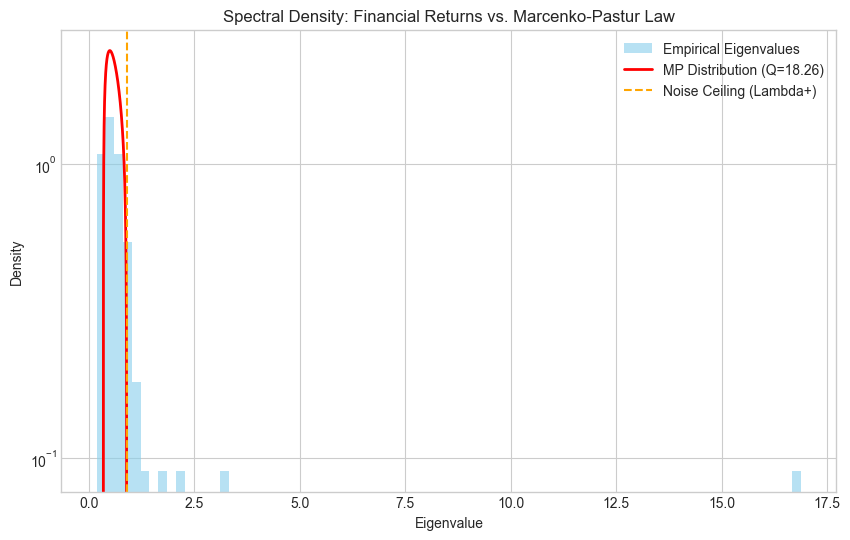

回测完成，样本外收益率已生成。


In [5]:
if 'df' not in locals():
    df = pd.read_csv('../data/market_tracks_real_89.csv', index_col=0, parse_dates=True)
    print("sucessfully loaded df from disk.")
plot_spectral_analysis(df)
# 1. 启动滚动回测
engine = OutOfSampleEngine(df, window_size=252)
oos_returns, oos_weights = engine.run_rolling_cleaning()

print("回测完成，样本外收益率已生成。")

# 2. 计算基准（未去噪的样本矩阵）作为对比
base_returns, _ = engine.run_rolling_cleaning(method='sample') 

# 3. 计算风险指标
risk_report = RiskMetrics.calculate_all(oos_returns)


# 4. 计算信息系数（IC）分析
oos_weights.index = df.index[252 : -1] 
shifted_returns = df.shift(-1) 
ic_report = ICAnalyzer.analyze(oos_weights, shifted_returns)

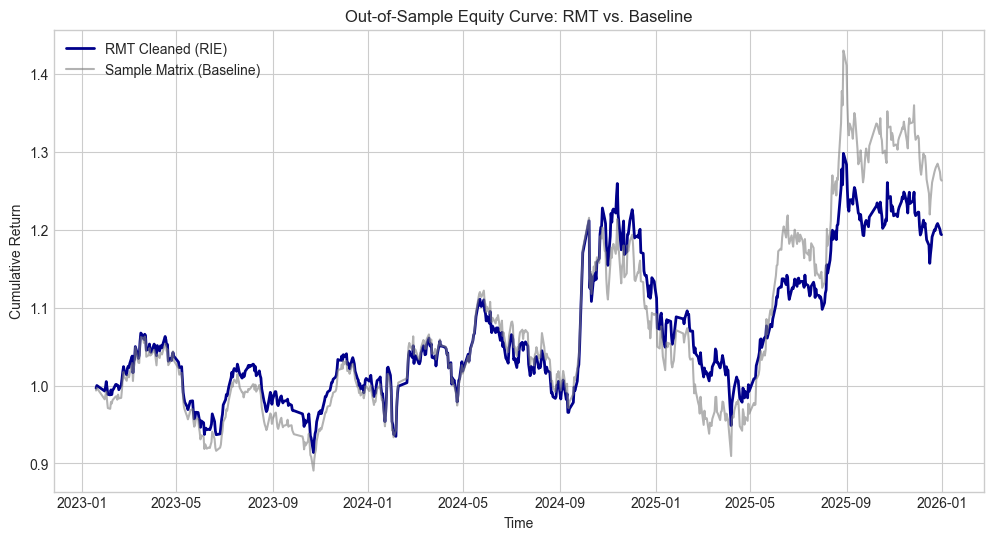

In [6]:
def plot_performance(oos_returns, base_returns=None):
    plt.figure(figsize=(12, 6))
    
    # RMT 清洗后的净值
    cum_rmt = (1 + oos_returns).cumprod()
    plt.plot(cum_rmt, label='RMT Cleaned (RIE)', color='darkblue', lw=2)
    
    # 基准净值
    if base_returns is not None:
        cum_base = (1 + base_returns).cumprod()
        plt.plot(cum_base, label='Sample Matrix (Baseline)', color='gray', alpha=0.6)
    
    plt.title("Out-of-Sample Equity Curve: RMT vs. Baseline")
    plt.xlabel("Time")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.show()

plot_performance(oos_returns, base_returns)

In [7]:
print("="*50)
print("             QUANT RESEARCH REPORT              ")
print("="*50)
print(f"{'Metric':<25} | {'Value':<15}")
print("-" * 45)
print(f"{'Mean Rank IC':<25} | {ic_report['Mean Rank IC']:>15.4f}")
print(f"{'IC t-stat':<25} | {ic_report['IC t-stat']:>15.2f}")
print(f"{'P-value':<25} | {ic_report['p-value']:>15.4f}")
print("-" * 45)
print(f"{'Annualized Return':<25} | {risk_report['Annualized Return']:>15.2%}")
print(f"{'Sharpe Ratio':<25} | {risk_report['Sharpe Ratio']:>15.2f}")
print(f"{'Max Drawdown':<25} | {risk_report['Max Drawdown']:>15.2%}")
print("="*50)

# 调试 1: 检查日期索引
print(f"Index Type: {type(oos_returns.index)}")
print(f"First 3 Dates:\n{oos_returns.index[:3]}")

# 调试 2: 验证手续费
# 如果 fee > 0 且权重在变动，net_ret 一定小于直接点积的结果
# 你可以对比某一天的 gross_ret 和 net_ret
print(f"\nMax Daily Net Return: {oos_returns.max():.4f}")

# 调试 3: RMT 修正检查 (针对 89 只股票)
Q_val = 252 / 89
in_sample = df.iloc[:252]
c_orig = in_sample.corr().values
cleaner = OptimalRIE(c_orig, Q_val)
c_clean, _ = cleaner.clean()
# 如果 Frobenius Norm 很大（比如你之前的 5.96），说明去噪非常剧烈
print("\nMatrix Difference (Frobenius Norm):", np.linalg.norm(c_orig - c_clean))

             QUANT RESEARCH REPORT              
Metric                    | Value          
---------------------------------------------
Mean Rank IC              |          0.0121
IC t-stat                 |            1.87
P-value                   |          0.0625
---------------------------------------------
Annualized Return         |           7.97%
Sharpe Ratio              |            0.43
Max Drawdown              |         -24.65%
Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
First 3 Dates:
DatetimeIndex(['2023-01-19', '2023-01-20', '2023-01-30'], dtype='datetime64[ns]', name='date', freq=None)

Max Daily Net Return: 0.0818

Matrix Difference (Frobenius Norm): 7.058221140057703
